<a href="https://colab.research.google.com/github/AndresMontesDeOca/Deep_Learning/blob/main/%20MONTES_DE_OCA-ANDRES-DL-TP1-Co25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Universidad de Buenos Aires - FIUBA - LSE
# Aprendizaje Profundo - TP1
# Cohorte 24 - 2do bimestre 2026

Este primer TP comienza la semana de la clase 2 y la ventana de entrega estará abierta hasta las **23:59 hs del jueves 21 de mayo (hora de Argentina)**. La resolución del TP es **individual**. Pueden utilizar tanto los contenidos vistos en clase, como otra bibliografía externa. Si se toman ideas de fuentes externas deben ser correctamente citadas incluyendo el correspondiente link o página de libro.

ESTE TP1 EQUIVALE A UN TERCIO DE SU NOTA FINAL.

El formato de entrega debe ser un link a un notebook de google colab. Importante permitir acceso a gvilcamiza.ext@fi.uba.ar y **habilitar los comentarios, para poder darles el feedback**. Si no lo hacen así no se podrá dar el feedback respectivo por cada pregunta.

**El desarrollo del TP se debe hacer obligatoriamente en un notebook**, ya sea en un Google Colab o en un Jupyter Notebook para quienes quieran desarrollarlo en su propia PC local. Pero no se aceptarán archivos `.py` o links a repos de github con múltiples archivos. El entregable debe ser un link a un único archivo `.ipynb`.

El envío **se realizará en el siguiente link de google forms: [link](https://forms.gle/dMmn8VEJmvRmYgvi6)**. Tanto los resultados, tablas, gráficas, como el código y las explicaciones deben quedar guardados y visualizables en el mismo notebook.

**NO SE VALIDARÁN ENVÍOS POR CORREO, EL ÚNICO MÉTODO DE ENTREGA ES SOLO POR EL FORMS.**

**Consideraciones a tener en cuenta:**
- Se entregará 1 solo colab para este TP1.
- Renombrar el archivo de la siguiente manera: **APELLIDO-NOMBRE-DL-TP1-Co24.ipynb**
- Los códigos deben poder ejecutarse.
- **IMPORTANTE:** Los resultados, cómo el código, los gráficos, los prints y las explicaciones deben quedar guardados y visualizables en el mismo notebook.
- **Prestar mucha atención a cada consigna, responder las preguntas justo debajo del enunciado que corresponda.**
- Solo se revisarán los trabajos que hayan sido enviados por el forms.

# **PREGUNTA 1** (Temas de la clase 1 y 2)

## **Comparación de Gradiente Descendente y Adam en una Función de Costo No Convexa**

En este ejercicio se compararán los optimizadores Gradiente Descendente (GD) y Adam en la minimización de una función de costo basada en una red neuronal de una sola conexión sináptica:
$$
z = w x + b
$$
Con función de activación tangente hiperbólica:

$$
\hat{y} = a(z) = \tanh(z) = \tanh(w x + b)
$$

<br>

Se analizará la trayectoria de aprendizaje de ambos algoritmos y se evaluará su eficiencia con diferentes tasas de aprendizaje (learning rate).

<br>

La función de costo utilizada es el Error Cuadrático Medio (MSE):

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}_i - y_i)^2
$$

$$
J(w, b) = \frac{1}{m} \sum_{i=1}^{m} ( \tanh(w x_i + b) - y_i )^2
$$

donde \\( w \\) y \\( b \\) son los parámetros a optimizar.

<br>

Si bien es cierto, en estos experimentos buscamos tan solo comparar optimizadores (GD vs Adam), de igual forma se necesitará una especie de dataset. Este será sintético y solo de prueba, por ende tendrán cierta libertad para elegir sus valores. Sin embargo deberán tomar en cuenta que cumpla la siguiente estructura:

`x = np.linspace(ini, fin, n)`

donde `x` es un array de una sola dimensión y con `n` cantidad de valores ($n>=200$). Y tiene un rango de valores desde `ini` hasta `fin`. Recomiendo que sea simétrico, es decir, los mismos valores solo que con el signo cambiado, por ejemplo `ini=-3, fin=3`, `ini=-5, fin=5`, `ini=-10, fin=10`, etc. Queda a elección de ustedes.

<br>

Y con un target `y`:

`y = funcion_no_lineal(x) + ruido`

donde `y` es también un vector de una sola dimensión de tamaño `n` que sigue un patrón no lineal (elegido por ustedes) con respecto a `x` adicionando un ruido que puede ser creado con algunas de las funciones del paquete `np.random`.

El patrón no lineal puede ser una función trigonométrica, exponencial, logarítmica, sigmoidal, polinómica de grado mayor o igual a 3, o la combinación de varias de estas (recomendado). Pero sean prudentes en la elección de la función no lineal, ya que recuerden que es una red de una sola conexión, por ende tampoco elijan algo tan complejo que al final provoque que el modelo no pueda converger.

### 1a) Implementación del Gradiente Descendente (1 punto)
- Implementar el algoritmo del Gradiente Descendente (GD) para minimizar \\( J(w, b) \\).
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Inicializar valores de \\( w \\) y \\( b \\) de manera aleatoria con `np.random.randn()`.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para los 3 learning rates. Las 3 gráficas deben estar en el mismo plot para que la comparación visual sea más fácil.

<br>

El optimizador del Gradiente Descendente se debe implementar haciendo el código desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciones Aux
def tanh(z):
    return np.tanh(z)

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def grad_mse_tanh(x, y_true, w, b):
    z = w * x + b
    y_pred = tanh(z)
    error = y_pred - y_true

    # Derivada de la activación tanh
    dtanh = 1 - y_pred**2

    # Gradientes vectorizados sobre el full batch
    dw = np.mean(2 * error * dtanh * x)
    db = np.mean(2 * error * dtanh)
    return dw, db, y_pred

In [43]:
# Construcción del Dataset Sintético
np.random.seed(1515)
m = 1000
x = np.linspace(-10, 10, m)

# Mapeo sigmoidal y ruido gaussiano
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y = 1 / (1 + np.exp(-x)) + ruido

# Setup
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()

# Proceso
historial_costos_gd = {}
y_pred_gd = {}

for lr in learning_rates:
    w, b = w_init, b_init
    costos = []

    for epoch in range(epochs):
        dw, db, y_pred = grad_mse_tanh(x, y, w, b)
        costos.append(mse_loss(y, y_pred))
        w -= lr * dw
        b -= lr * db

        if epoch == epochs - 1:
            y_pred_gd[lr] = y_pred

    historial_costos_gd[lr] = costos

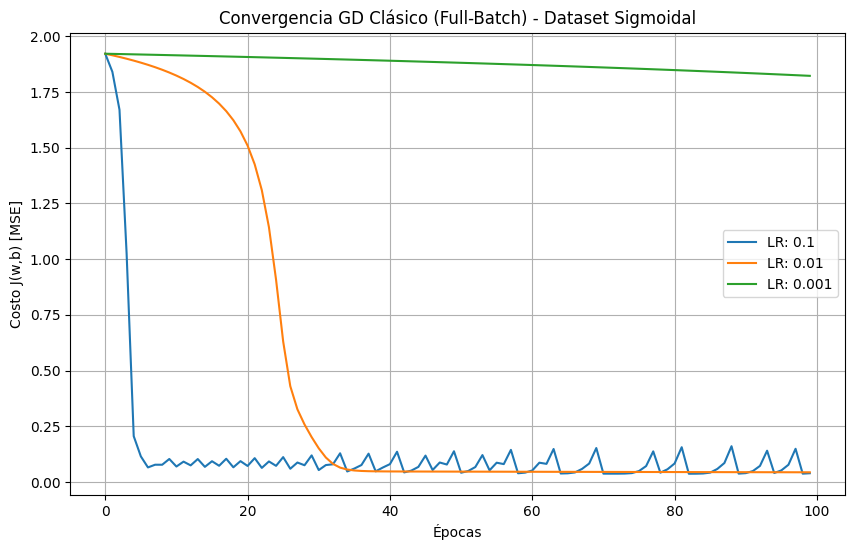

In [44]:
# Plot
plt.figure(figsize=(10, 6))
for lr, costos in historial_costos_gd.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title('Convergencia GD Clásico (Full-Batch) - Dataset Sigmoidal')
plt.legend()
plt.grid(True)
plt.show()

- Se observa como con un LR muy pequeno, tarda demasiado en converger
- En cambio, con un LR muy grande, se converge rapido pero es mucho mas inestable con el paso del tiempo
- Y con un LR medio, se ve como demora mas en converger, pero la misma es mucho mas suave y estable

### 1b) Implementación de Adam (2 punto)  
- Implementar el algoritmo de Adam para minimizar \\( J(w, b) \\).  
- Utilizar 100 épocas y 3 diferentes learning rates `(0.1, 0.01, 0.001)`.
- Utilizar los mismos valores de \\( w \\) y \\( b \\) que se usaron para GD **(IMPORTANTE)**.
- Hacer 2 modelos, uno sin mini-batch (full-batch) y otro con mini-batch.
- El batch size es a elección de ustedes, pero debe ser mayor o igual a 16.
- Graficar la función de Costo \\( J(w, b) \\) VS número de época para comparar cómo converge la función para ambos modelos y para los 3 learning rates. Deben haber 2 plots separados o 2 subplots, uno para las 3 gráficas de Adam full-batch y otro para las 3 gráficas de Adam mini-batch.

<br>

Al igual que para GD, ambas versiones del optimizador Adam también se deben implementar desde cero y paso a paso. Se pueden usar librerías como `numpy`, `scipy`, `matplotlib` o similares. Pero no está permitido usar PyTorch ni TensorFlow o frameworks que ya contengan el optimizador desarrollado.

In [45]:
# Adam Full-Batch
batch_size = 128
beta1, beta2, epsilon = 0.9, 0.999, 1e-8

historial_costos_adam_full = {lr: [] for lr in learning_rates}
y_pred_adam_full = {}

for lr in learning_rates:

    w_f, b_f = w_init, b_init # Mismos valores usados antes
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0

    for t in range(1, epochs + 1):
        dw, db, y_pred = grad_mse_tanh(x, y, w_f, b_f)
        historial_costos_adam_full[lr].append(mse_loss(y, y_pred))

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (W)
        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        # Propagación de estimadores de 1er y 2do momento con corrección de sesgo (B)
        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)


        if t == epochs:
            y_pred_adam_full[lr] = y_pred


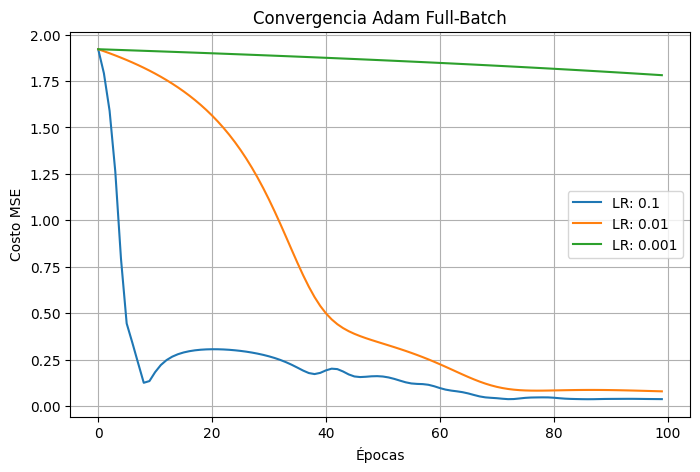

In [46]:
# Plot

plt.figure(figsize=(8, 5))
for lr in learning_rates:
    plt.plot(range(epochs), historial_costos_adam_full[lr], label=f'LR: {lr}')
plt.xlabel('Épocas')
plt.ylabel('Costo MSE')
plt.title('Convergencia Adam Full-Batch')
plt.legend()
plt.grid(True)

* Con un LR grande se logra estabilizar
* Hay un rebote inicial, pero los momentos del optimizador amortiguan el salto y lo llevan a convergencia

In [47]:
# Adam Mini-Batch


historial_costos_adam_mini = {}
y_pred_adam_mini = {}

for lr in learning_rates:
    w_m, b_m = w_init, b_init # Mismos valores usados antes

    # Inicialización nula de estimadores de momento
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    costos = []

    for epoch in range(epochs):

        indices = np.random.permutation(m)
        x_shuf, y_shuf = x[indices], y[indices]

        for i in range(0, m, batch_size):
            # Extracción asimétrica de tensores de lote
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]

            # Aproximación del gradiente sobre el sub-tensor X_b
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            # Estimadores de momento y corrección de sesgo adaptativo (Tensor W)
            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            # Estimadores de momento y corrección de sesgo adaptativo (Escalar B)
            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

        # Evaluación del costo global sobre la matriz X completa tras iterar los n/b lotes
        _, _, y_pred_full = grad_mse_tanh(x, y, w_m, b_m)
        costos.append(mse_loss(y, y_pred_full))

        if epoch == epochs - 1:
            y_pred_adam_mini[lr] = y_pred_full

    historial_costos_adam_mini[lr] = costos

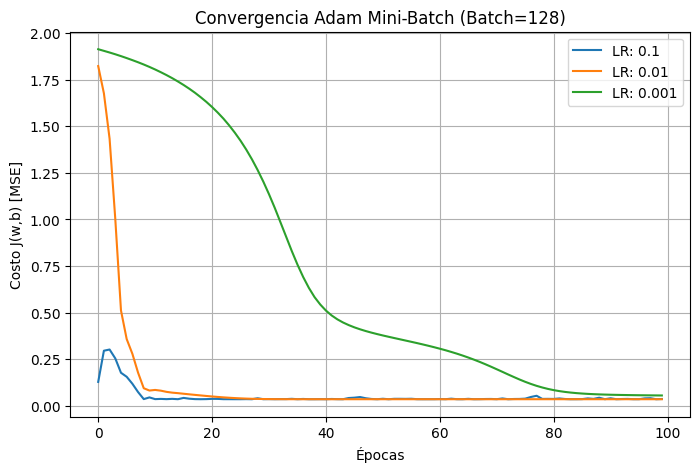

In [48]:
# Plot
plt.figure(figsize=(8, 5))
for lr, costos in historial_costos_adam_mini.items():
    plt.plot(range(epochs), costos, label=f'LR: {lr}')

plt.xlabel('Épocas')
plt.ylabel('Costo J(w,b) [MSE]')
plt.title(f'Convergencia Adam Mini-Batch (Batch={batch_size})')
plt.legend()
plt.grid(True)
plt.show()

* Al actualizar los pesos por cada lote (y no al final de toda la epoca), el tiempo de convergencia se reduce para todos los LRs
* Esto permite converger utilizando LRs pequenos, a diferencia de los metodos anteriores

### 1c) Comparativa de optimizadores (0.5 puntos)  
- Comparar el resultado y rendimiento de GD VS Adam (full-batch) VS Adam (mini-batch) para cada uno de los learning rates por separado. Hacerlo con gráficas y tablas. Deben haber 3 plots o 3 subplots, uno para cada learning rate.
- Graficar el dataset original sintético (y(x)) y compararlo con la función hallada por el modelo, para ver si efectivamente el modelo logró deducir un patrón no lineal parecido al patrón no lineal escogido para el dataset. Hacerlo para cada optimizador y cada learning rate en un plot grande de 9 subplots.
- Redactar conclusiones analíticas que resalten las diferencias entre cada optimizador. No solo deben comparar el resultado final del costo, sino también la velocidad de convergencia y otros aspectos que consideren relevantes.

Métricas de convergencia terminal (Época 100):


<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
<>:32: SyntaxWarning: invalid escape sequence '\h'
<>:51: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_9224/3684211359.py:32: SyntaxWarning: invalid escape sequence '\h'
  fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')
/tmp/ipykernel_9224/3684211359.py:51: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')


,Learning Rate (η),GD (MSE),Adam Full-Batch (MSE),Adam Mini-Batch (MSE)
0,0.100,0.039277,0.036868,0.037456
1,0.010,0.043528,0.078840,0.036288
2,0.001,1.822200,1.781575,0.056346


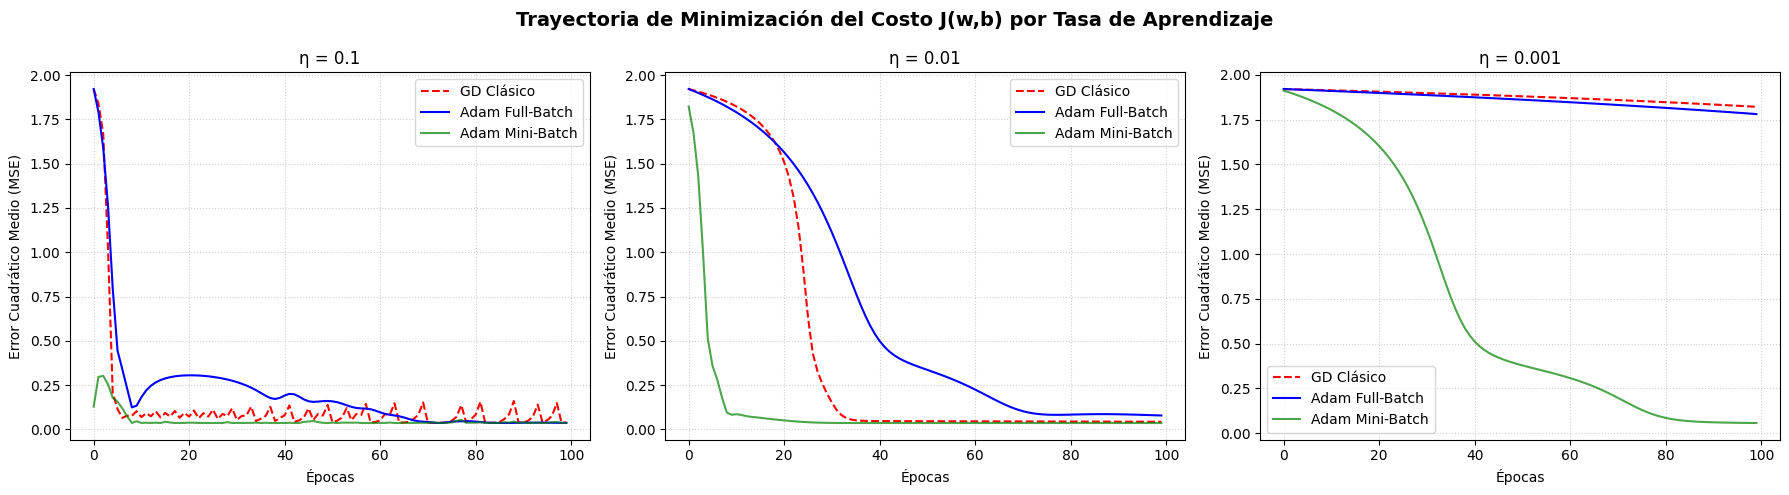

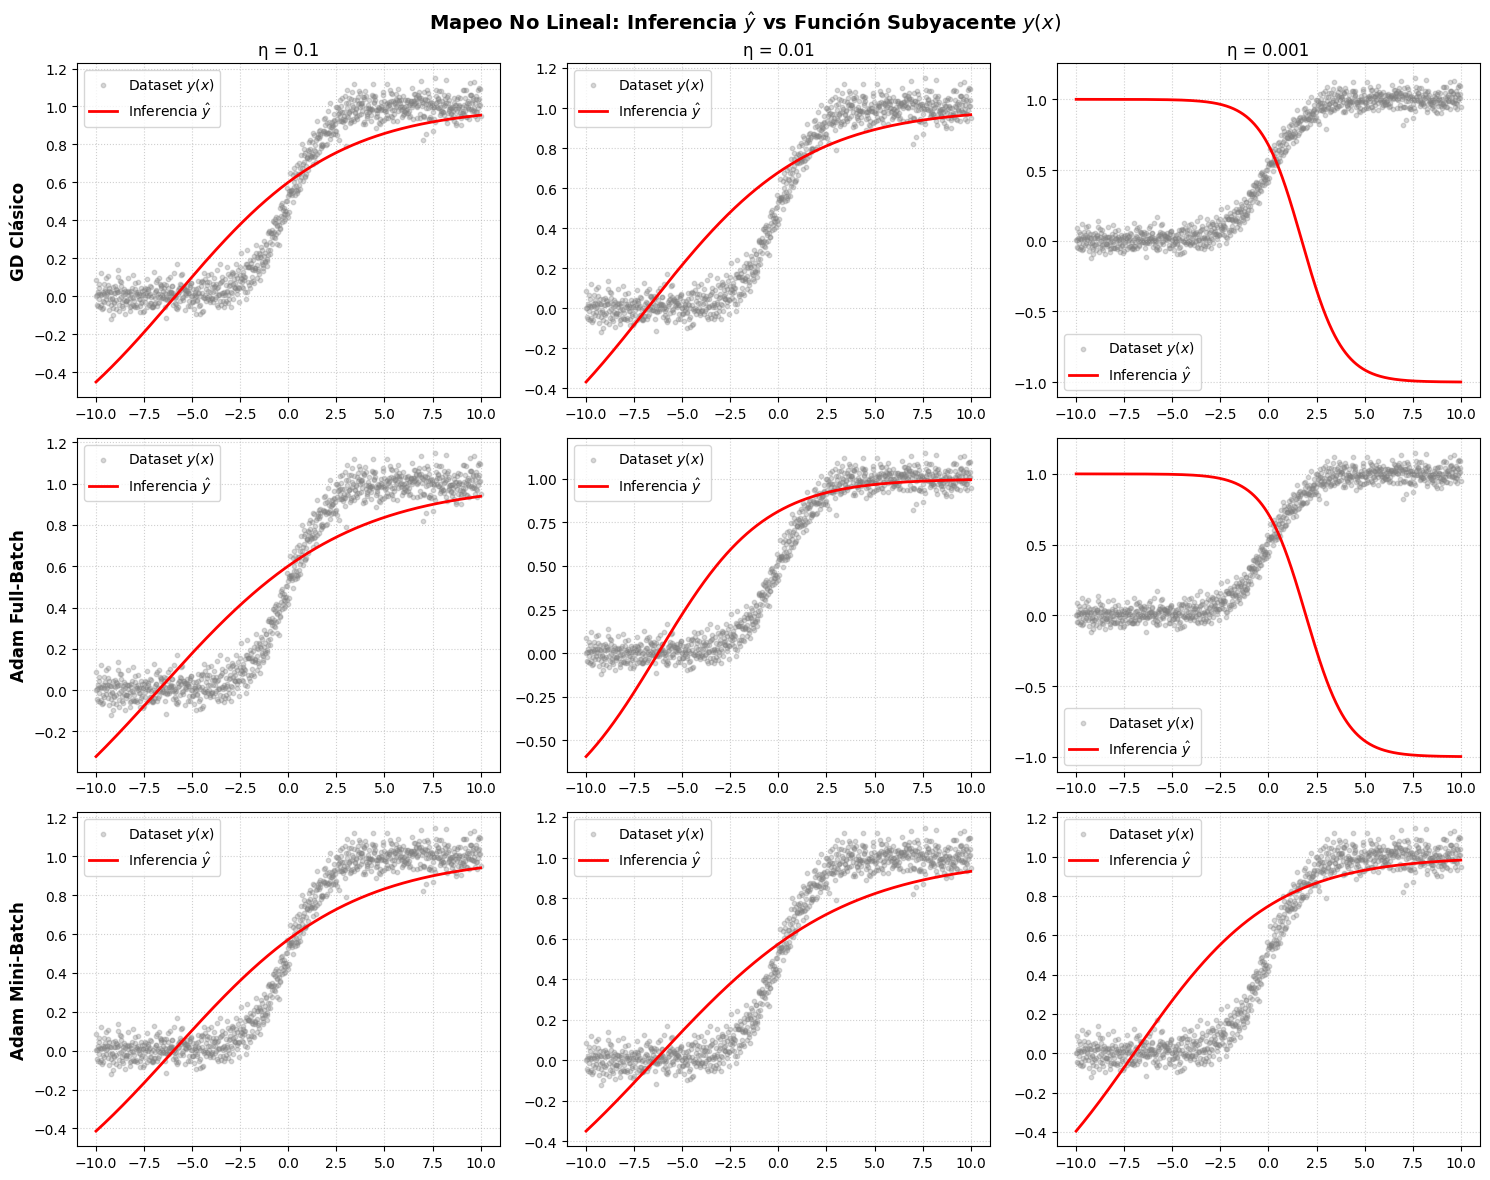

In [49]:
# 1. Matriz Analítica de Rendimiento Asintótico
df_mse = pd.DataFrame({
    'Learning Rate (η)': learning_rates,
    'GD (MSE)': [historial_costos_gd[lr][-1] for lr in learning_rates], # Puntero adaptado a tu nomenclatura base
    'Adam Full-Batch (MSE)': [historial_costos_adam_full[lr][-1] for lr in learning_rates],
    'Adam Mini-Batch (MSE)': [historial_costos_adam_mini[lr][-1] for lr in learning_rates]
})

print("Métricas de convergencia terminal (Época 100):")
display(df_mse)

# 2. Análisis Topológico de la Convergencia de J(w,b) (3 Subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Trayectoria de Minimización del Costo J(w,b) por Tasa de Aprendizaje', fontsize=14, fontweight='bold')

for i, lr in enumerate(learning_rates):
    axes[i].plot(range(epochs), historial_costos_gd[lr], label='GD Clásico', linestyle='--', color='red')
    axes[i].plot(range(epochs), historial_costos_adam_full[lr], label='Adam Full-Batch', color='blue')
    axes[i].plot(range(epochs), historial_costos_adam_mini[lr], label='Adam Mini-Batch', color='green', alpha=0.7)

    axes[i].set_title(f'η = {lr}')
    axes[i].set_xlabel('Épocas')
    axes[i].set_ylabel('Error Cuadrático Medio (MSE)')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Proyección del Hiperplano Inferido vs Dataset Original (Grilla 3x3)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Mapeo No Lineal: Inferencia $\hat{y}$ vs Función Subyacente $y(x)$', fontsize=14, fontweight='bold')

optimizadores = [
    ('GD Clásico', y_pred_gd), # Reemplazar por y_pred si no utilizaste el sufijo _gd
    ('Adam Full-Batch', y_pred_adam_full),
    ('Adam Mini-Batch', y_pred_adam_mini)
]

# Ordenamiento del tensor unidimensional para asegurar una interpolación continua
idx_sort = np.argsort(x)

for row, (nombre_opt, predicciones) in enumerate(optimizadores):
    for col, lr in enumerate(learning_rates):
        ax = axes[row, col]

        # Dispersión estocástica del dataset
        ax.scatter(x, y, color='gray', alpha=0.3, label='Dataset $y(x)$', s=10)

        # Interpolación de la predicción
        ax.plot(x[idx_sort], predicciones[lr][idx_sort], color='red', linewidth=2, label='Inferencia $\hat{y}$')

        if row == 0:
            ax.set_title(f'η = {lr}')
        if col == 0:
            ax.set_ylabel(nombre_opt, fontweight='bold', fontsize=12)

        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend()

plt.tight_layout()
plt.show()

- Para los LRs de 0.1 y 0.01, los tres algoritmos predicen bastante bien, con un MSE que ronda entre 0.035 y 0.7
- Tambien se observa en los plots, como como para esos LRs, la inferencia sigue un patron similar al de la distribucion original (sigmoide + random)
- En cambio para el LR mas chico (0.001), los algoritmos GD y Adan Full Batch no convergen. Desvanecimiento del Gradiente? Minimo Local?

- Adam Mini-Batch demuestra robustez transversal, logrando converger eficientemente con cualquier LR


### 1d) Visualización en 3D de la trayectoria de aprendizaje (0.5 puntos)
- Graficar en 3D la trayectoria del aprendizaje de los 3 optimizadores sobre la superficie de la función de costo \\( J(w, b) \\). Se debe elegir un solo learning rate, el que consideres que se nota mejor la diferencia.
- Las 3 trayectorias deben estar en la misma superficie 3D y empezar en el mismo punto.
- Recomiendo utilizar `mpl_toolkits.mplot3d` y `np.meshgrid`, pero queda a su criterio la elección de funciones a usar para lograr el gráfico. También si desean pueden hacer que el gráfico sea animado usando `matplotlib.animation` y `IPython.display`.
- Comparar y redactar cómo se mueven en el espacio de parámetros y qué diferencias existen en la convergencia.

In [75]:
import numpy as np

# Re-define the synthetic dataset for this section (originally from cell gxwZwvZYLPdy)
np.random.seed(1515)
m = 1000
x_synthetic = np.linspace(-10, 10, m)
ruido = np.random.normal(loc=0.0, scale=0.05, size=m)
y_synthetic = 1 / (1 + np.exp(-x_synthetic)) + ruido

# Setup for optimizers (epochs, learning_rates, initial weights, etc.)
epochs = 100
learning_rates = [0.1, 0.01, 0.001]
w_init, b_init = np.random.randn(), np.random.randn()



# GD Clásico
historial_w_gd = {} # Almacena w en cada época
historial_b_gd = {} # Almacena b en cada época

for lr in learning_rates:
    w, b = w_init, b_init
    ws, bs = [], []
    for epoch in range(epochs):
        ws.append(w)
        bs.append(b)
        # Use synthetic data for this section
        dw, db, _ = grad_mse_tanh(x_synthetic, y_synthetic, w, b)
        w -= lr * dw
        b -= lr * db
    historial_w_gd[lr] = ws
    historial_b_gd[lr] = bs

# Adam Full-Batch
historial_w_adam_full = {} # Almacena w en cada época
historial_b_adam_full = {} # Almacena b en cada época

for lr in learning_rates:
    w_f, b_f = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    ws_f, bs_f = [], []
    for t in range(1, epochs + 1):
        ws_f.append(w_f)
        bs_f.append(b_f)
        # Use synthetic data for this section
        dw, db, _ = grad_mse_tanh(x_synthetic, y_synthetic, w_f, b_f)

        m_w = beta1 * m_w + (1 - beta1) * dw
        v_w = beta2 * v_w + (1 - beta2) * (dw**2)
        w_f -= lr * (m_w / (1 - beta1**t)) / (np.sqrt(v_w / (1 - beta2**t)) + epsilon)

        m_b = beta1 * m_b + (1 - beta1) * db
        v_b = beta2 * v_b + (1 - beta2) * (db**2)
        b_f -= lr * (m_b / (1 - beta1**t)) / (np.sqrt(v_b / (1 - beta2**t)) + epsilon)
    historial_w_adam_full[lr] = ws_f
    historial_b_adam_full[lr] = bs_f

# Adam Mini-Batch
historial_w_adam_mini = {} # Almacena w en cada época
historial_b_adam_mini = {} # Almacena b en cada época

# Define beta1, beta2, epsilon, and batch_size if not already defined
# (These were defined in bd2wWPyXUPSu, but good to ensure local scope if needed)
beta1, beta2, epsilon = 0.9, 0.999, 1e-8
batch_size = 128 # Or whatever batch_size was intended for this part

for lr in learning_rates:
    w_m, b_m = w_init, b_init
    m_w, v_w, m_b, v_b = 0.0, 0.0, 0.0, 0.0
    t_m = 1
    ws_m, bs_m = [], []

    for epoch in range(epochs):
        # Almacenar w y b al inicio de cada época (después de las actualizaciones del epoch anterior)
        ws_m.append(w_m)
        bs_m.append(b_m)

        # Use m from synthetic dataset
        indices = np.random.permutation(m)
        x_shuf, y_shuf = x_synthetic[indices], y_synthetic[indices]

        for i in range(0, m, batch_size):
            x_b = x_shuf[i:i + batch_size]
            y_b = y_shuf[i:i + batch_size]
            # Use synthetic data for this section
            dw, db, _ = grad_mse_tanh(x_b, y_b, w_m, b_m)

            m_w = beta1 * m_w + (1 - beta1) * dw
            v_w = beta2 * v_w + (1 - beta2) * (dw**2)
            m_w_hat = m_w / (1 - beta1**t_m)
            v_w_hat = v_w / (1 - beta2**t_m)
            w_m -= lr * m_w_hat / (np.sqrt(v_w_hat) + epsilon)

            m_b = beta1 * m_b + (1 - beta1) * db
            v_b = beta2 * v_b + (1 - beta2) * (db**2)
            m_b_hat = m_b / (1 - beta1**t_m)
            v_b_hat = v_b / (1 - beta2**t_m)
            b_m -= lr * m_b_hat / (np.sqrt(v_b_hat) + epsilon)

            t_m += 1

    historial_w_adam_mini[lr] = ws_m
    historial_b_adam_mini[lr] = bs_m

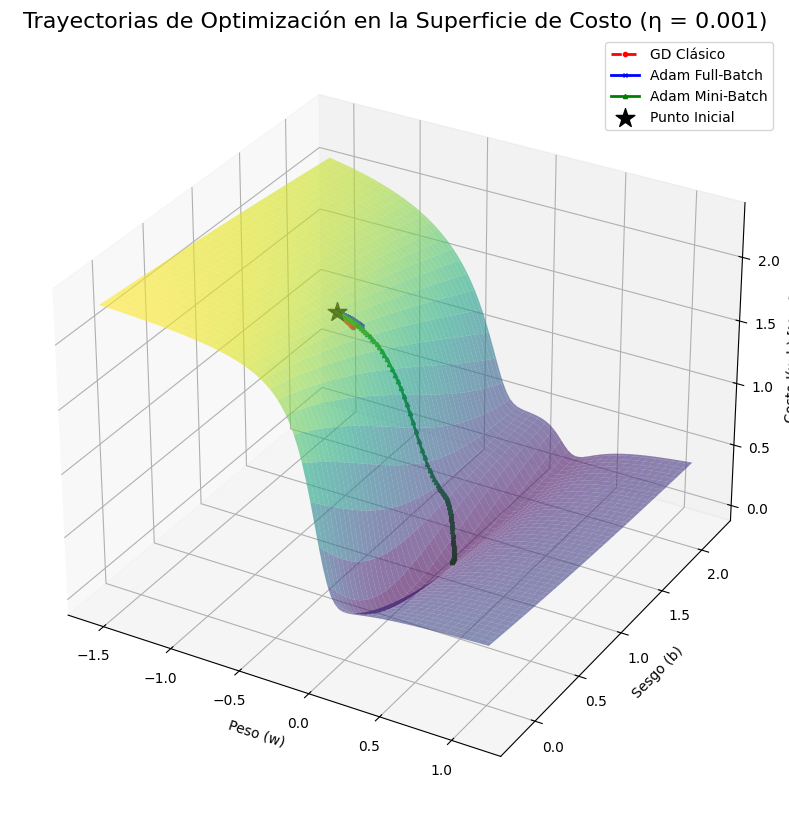

In [77]:
from mpl_toolkits.mplot3d import Axes3D

# Definir la función de costo J(w, b) para la superficie
def J_surface(w, b, X_data, y_data):
    cost_val = np.zeros_like(w)
    for i in range(w.shape[0]):
        for j in range(w.shape[1]):
            z = w[i, j] * X_data + b[i, j]
            y_pred = tanh(z)
            cost_val[i, j] = mse_loss(y_data, y_pred)
    return cost_val

# Seleccionar un learning rate para la visualización 3D
l_rate_3d = 0.001

# Obtener las trayectorias para el LR seleccionado
trajectory_w_gd = historial_w_gd[l_rate_3d]
trajectory_b_gd = historial_b_gd[l_rate_3d]
trajectory_J_gd = historial_costos_gd[l_rate_3d]

trajectory_w_adam_full = historial_w_adam_full[l_rate_3d]
trajectory_b_adam_full = historial_b_adam_full[l_rate_3d]
trajectory_J_adam_full = historial_costos_adam_full[l_rate_3d]

trajectory_w_adam_mini = historial_w_adam_mini[l_rate_3d]
trajectory_b_adam_mini = historial_b_adam_mini[l_rate_3d]
trajectory_J_adam_mini = historial_costos_adam_mini[l_rate_3d]

# Definir el rango para w y b para la superficie de costo
# Ajustar los límites para que cubran las trayectorias de los tres optimizadores
min_w = min(np.min(trajectory_w_gd), np.min(trajectory_w_adam_full), np.min(trajectory_w_adam_mini)) - 1
max_w = max(np.max(trajectory_w_gd), np.max(trajectory_w_adam_full), np.max(trajectory_w_adam_mini)) + 1
min_b = min(np.min(trajectory_b_gd), np.min(trajectory_b_adam_full), np.min(trajectory_b_adam_mini)) - 1
max_b = max(np.max(trajectory_b_gd), np.max(trajectory_b_adam_full), np.max(trajectory_b_adam_mini)) + 1

w_range = np.linspace(min_w, max_w, 100)
b_range = np.linspace(min_b, max_b, 100)
W, B = np.meshgrid(w_range, b_range)

# Calcular la superficie de costo, usando x_synthetic y y_synthetic
Z = J_surface(W, B, x_synthetic, y_synthetic)

# Graficar
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Superficie de costo
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)

# Trayectoria GD Clásico
ax.plot(trajectory_w_gd, trajectory_b_gd, trajectory_J_gd,
        label='GD Clásico', color='red', marker='o', markersize=3, linestyle='--', linewidth=2)

# Trayectoria Adam Full-Batch
ax.plot(trajectory_w_adam_full, trajectory_b_adam_full, trajectory_J_adam_full,
        label='Adam Full-Batch', color='blue', marker='x', markersize=3, linestyle='-', linewidth=2)

# Trayectoria Adam Mini-Batch
ax.plot(trajectory_w_adam_mini, trajectory_b_adam_mini, trajectory_J_adam_mini,
        label='Adam Mini-Batch', color='green', marker='^', markersize=3, linestyle='-', linewidth=2)

# Punto inicial (todos comienzan en el mismo lugar)
ax.scatter(w_init, b_init, historial_costos_gd[l_rate_3d][0],
           color='black', marker='*', s=200, label='Punto Inicial', zorder=10)

ax.set_xlabel('Peso (w)')
ax.set_ylabel('Sesgo (b)')
ax.set_zlabel('Costo J(w,b) [MSE]')
ax.set_title(f'Trayectorias de Optimización en la Superficie de Costo (η = {l_rate_3d})', fontsize=16)
ax.legend()
plt.show()

- Para un learning rate pequeño como 0.001, los métodos que dependen de gradientes más estables (GD y Adam Full-Batch) pueden volverse excesivamente lentos y quedar atrapados (no converger)
- En contraste, Adam Mini-Batch, con su combinación de momentos adaptativos y ruido de mini-batches, puede navegar la superficie de costo de manera más dinámica y eficiente, logrando la convergencia donde otros fallan

### **RECOMENDACIÓN**:

Voy a valorar mucho que sus análisis, explicaciones y conclusiones sean bastante detalladas y con coherencia en los resultados obtenidos. Donde se evidencie un análisis propio de un humano estudiante de posgrado y no solo copiar y pegar lo que te dijo ChatGPT. Llevo ya años con esto, así que me daré cuenta rapidamente cuando sea así y cuando no.

Les recomiendo revisar el notebook sobre optimizadores que se encuentra en el repo. Pueden acceder mediante el siguiente [enlace](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/blob/ap_2026/CLASE%202/Notebooks/clase2_4_optimizadores.ipynb). En ese notebook vemos cómo aplicar GD y Adam full-batch para una red con relación lineal. Les servirá mucho como guía para realizar esta pregunta. Ahí también podrán ver cómo se hace una animación de un gráfico 3D.

Además, de igual forma tienen disponible el siguiente [material adicional del repo](https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/aprendizaje_profundo/tree/ap_2026/CLASE%202/Teoria/Material%20adicional), el cual le servirá para aplicar Adam, ya no solo en su versión full-batch, sino también en mini-batch

# **PREGUNTA 2** (Temas de la clase 3)

# Caso: Predicción del gasto promedio de los usuarios usando redes neuronales

**Descarga del dataset:**  
El conjunto de datos puede descargarse en el siguiente [enlace](https://drive.google.com/file/d/1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ/view?usp=sharing)

---

## Descripción general:

El dataset recopila información sobre las compras realizadas por distintos clientes en una tienda durante el último año.  
Cada registro representa una transacción e incluye datos tanto del cliente como del producto adquirido.

---

## El dataset contiene la siguiente información:

- **User_ID:** Código identificador único del cliente que efectuó la compra.  
- **Product_ID:** Código identificador único del producto adquirido.  
- **Age:** Rango de edad del cliente.  
- **Gender:** Género del cliente (F: Femenino, M: Masculino).  
- **Marital_Status:** Estado civil del cliente (0: Soltero, 1: Casado).  
- **City_Category:** Tipo de zona donde se encuentra la sucursal donde se realizó la compra.  
  - A: Barrio de clase alta  
  - B: Barrio de clase media  
  - C: Barrio de clase media-baja  
- **Stay_In_Current_City_Years:** Número de años que el cliente ha venido comprando en la tienda desde su primera visita.  
- **Product_Category:** Categoría del producto comprado.  
- **Product_Subcategory_1:** Subcategoría principal del producto.  
- **Product_Subcategory_2:** Subcategoría secundaria del producto.  
- **Purchase:** Monto pagado por el producto en esa transacción.

---

## Objetivo del caso de estudio:

Desarrollar un **modelo predictivo** capaz de estimar el **gasto promedio** que realizará un cliente, a partir de su información demográfica y sus patrones de compra. Tener en cuenta que se busca que el modelo prediga el gasto promedio por cliente, no el gasto en cada nueva transacción individual.


### 2a) EDA y preparación del dataset (2 puntos)
Realizar el análisis exploratorio del dataset (EDA) con las herramientas vistas en materias anteriores.
- Analizar qué columnas sirven para lograr el objetivo y cuáles no (drop) en base al contexto del negocio y a lo entendido del caso de estudio (feature engineering).
- Analizar con qué columnas vale la pena hacer un tratamiento de valores nulos o si simplemente se debe dropear toda la columna porque ya no tiene salvación.
- Analizar a qué variables se les debe hacer label encoding, a cuáles one-hot encoding, ordinal encoding o mapping encoding. Explicar detalladamente los criterios utilizados para tomar esas decisiones.
- Transformar, agrupar, combinar y operar la data de tal manera que sea útil para extraer patrones de gastos y tendencias de gustos de cada cliente. **Tener mucho cuidado con el data leakage**.



Redactar las conclusiones preliminares que puedan notar de cada feature y justificar el porqué de cada encoding, limpieza o transformación aplicada. Cada justificación se debe redactar a detalle y sustentar con gráficas y/o tablas.


In [52]:
import pandas as pd
import gdown
import os
import matplotlib.pyplot as plt

# Google Drive file ID for the dataset
file_id = '1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ'

# Output filename
output_filename = 'customer_data.csv'

# Download the file from Google Drive using gdown
gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1e_FRepCpHBWWGj3TYG4HY7WHALCyR4wQ
To: /content/customer_data.csv
100%|██████████| 8.41M/8.41M [00:00<00:00, 199MB/s]


'customer_data.csv'

In [53]:
# Load the CSV file into a pandas DataFrame
data = pd.read_csv(output_filename)

# Display the first 5 rows of the DataFrame
print(f"Successfully loaded '{output_filename}' into a DataFrame. First 5 rows:")
display(data.head())

Successfully loaded 'customer_data.csv' into a DataFrame. First 5 rows:


,User_ID,Product_ID,Age,Gender,Marital_Status,City_Category,Stay_In_Current_City_Years,Product_Category,Product_Subcategory_1,Product_Subcategory_2,Purchase
0,1044096,P00017122,46-50,F,1,B,1,10,45.0,NaN,1810
1,1071818,P00074517,36-45,M,0,A,3,11,27.0,NaN,12351
2,1022986,P00013694,36-45,M,1,A,5+,4,28.0,NaN,127
3,1094684,P00049122,36-45,M,1,A,1,16,9.0,8.0,2214
4,1004157,P00006469,46-50,M,1,A,5+,3,NaN,NaN,7142


In [54]:
print(f"Shape of the DataFrame: {data.shape}")
print("Data types of the columns:")
display(data.info())

Shape of the DataFrame: (182721, 11)
Data types of the columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     182721 non-null  int64  
 1   Product_ID                  182721 non-null  object 
 2   Age                         182721 non-null  object 
 3   Gender                      182721 non-null  object 
 4   Marital_Status              182721 non-null  int64  
 5   City_Category               182721 non-null  object 
 6   Stay_In_Current_City_Years  182721 non-null  object 
 7   Product_Category            182721 non-null  int64  
 8   Product_Subcategory_1       140903 non-null  float64
 9   Product_Subcategory_2       77461 non-null   float64
 10  Purchase                    182721 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 15.3+ MB


None

In [55]:
print("Percentage of missing values per column:")
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_percentage})
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Percentage', ascending=False))

Percentage of missing values per column:


,Missing Count,Percentage
Product_Subcategory_2,105260,57.606953
Product_Subcategory_1,41818,22.886258


- Pendiente que hacer con los nulos

In [56]:
# Transformamos las enteras que son categoricas por el EDA
data = data.astype({
    'Marital_Status': 'object',
    'Product_Category': 'object',
    'Product_Subcategory_1': 'object',
    'Product_Subcategory_2': 'object'

})

Unique values and counts for categorical columns:

Column: Age


<Axes: xlabel='Age'>

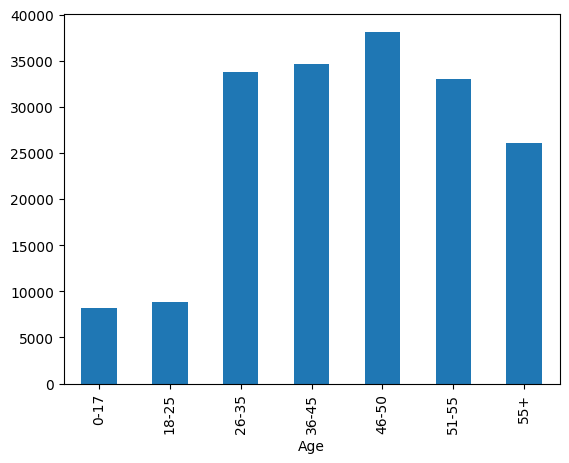

Number of unique values: 7

Column: Gender


<Axes: xlabel='Gender'>

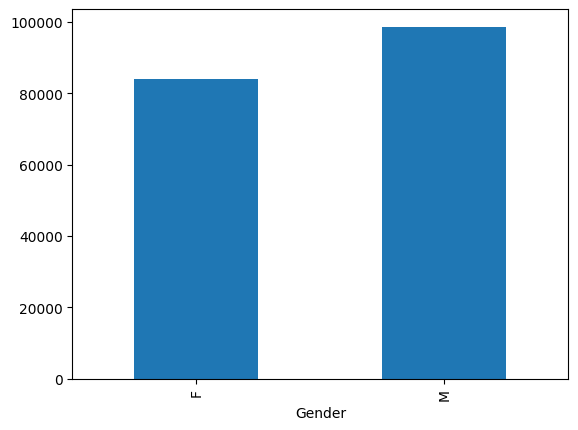

Number of unique values: 2

Column: Marital_Status


<Axes: xlabel='Marital_Status'>

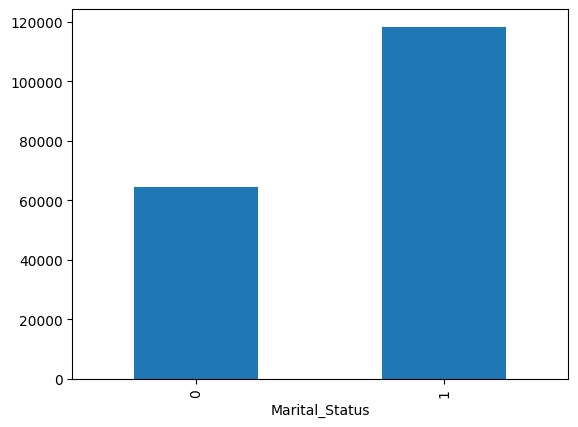

Number of unique values: 2

Column: City_Category


<Axes: xlabel='City_Category'>

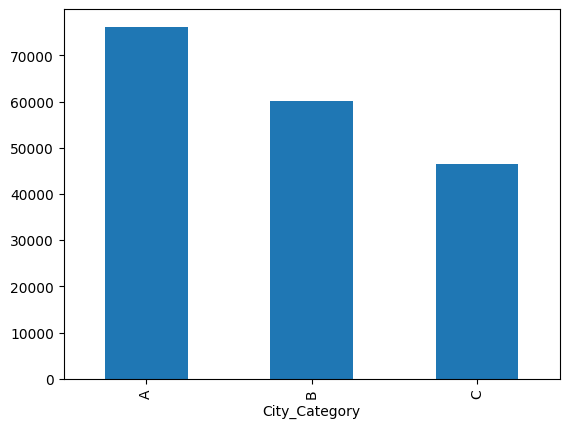

Number of unique values: 3

Column: Stay_In_Current_City_Years


<Axes: xlabel='Stay_In_Current_City_Years'>

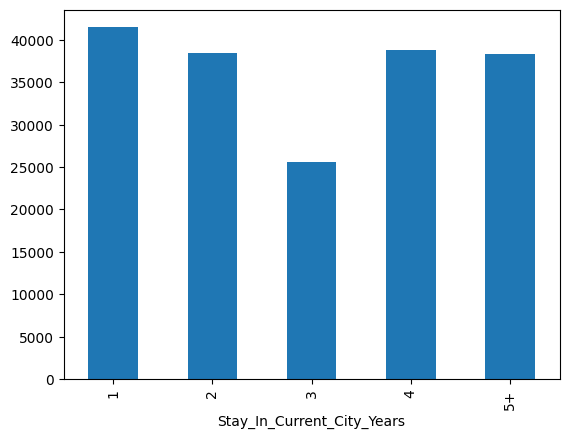

Number of unique values: 5

Column: Product_Category


<Axes: xlabel='Product_Category'>

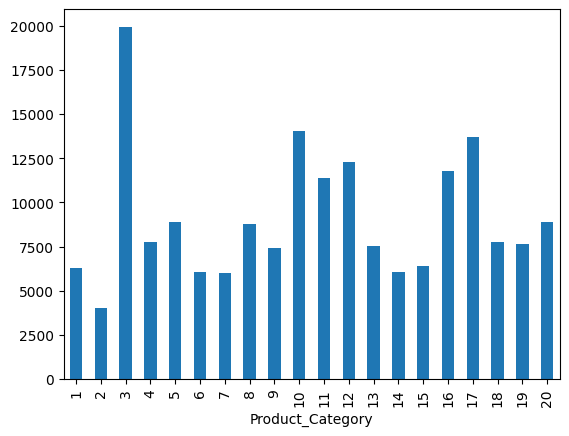

Number of unique values: 20

Column: Product_Subcategory_1


<Axes: xlabel='Product_Subcategory_1'>

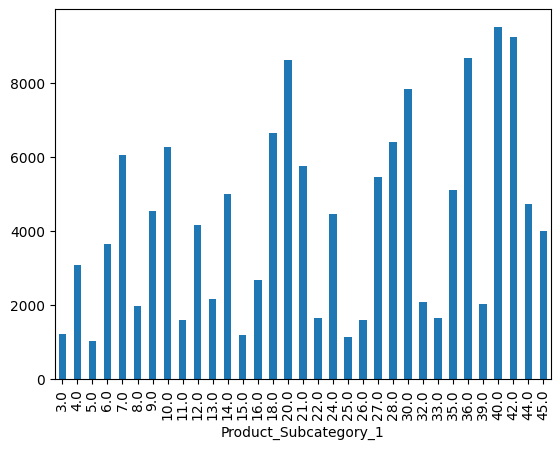

Number of unique values: 33

Column: Product_Subcategory_2


<Axes: xlabel='Product_Subcategory_2'>

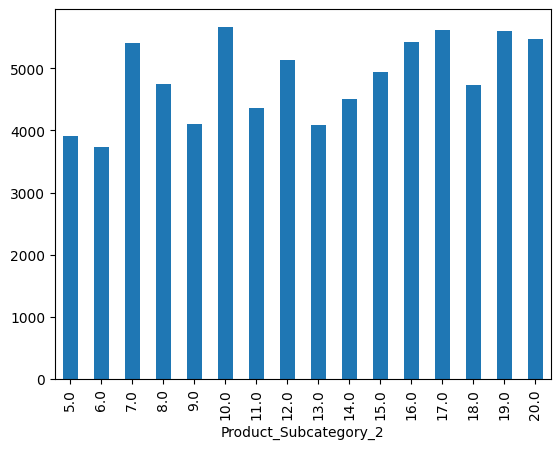

Number of unique values: 16


In [57]:
# Identify categorical columns (object dtype)
categorical_cols = data.select_dtypes(include=['object']).columns
categorical_cols = categorical_cols.drop('Product_ID') # No suma

print("Unique values and counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    display(data[col].value_counts().sort_index().plot(kind='bar')) # Mejor ploteamos
    plt.show()
    print(f"Number of unique values: {data[col].nunique()}")

* Categoricas Ordinales:  Age, City_Category y Stay_In_Current_City_Years
* Booleanas: Gender y Marital_Status

In [58]:
# Transformamos las Ordinales

from sklearn.preprocessing import OrdinalEncoder

# Define the categories for each feature in their correct ordinal order
age_categories = ['0-17', '18-25', '26-35', '36-45', '46-50', '51-55', '55+']
city_categories = ['A', 'B', 'C'] # Assuming A < B < C
stay_years_categories = ['0', '1', '2', '3', '4', '5+']

# Create an OrdinalEncoder instance with the defined categories
# Handle unknown categories by encoding them as the last category, or raise an error if preferred
encoder = OrdinalEncoder(
    categories=[age_categories, city_categories, stay_years_categories],
    handle_unknown='use_encoded_value',
    unknown_value=-1 # Assign -1 to unknown categories, or choose another appropriate value
)

# Apply ordinal encoding to the specified columns
data[['Age', 'City_Category', 'Stay_In_Current_City_Years']] = encoder.fit_transform(
    data[['Age', 'City_Category', 'Stay_In_Current_City_Years']]
)

# Renombramos
data.rename(columns={
    'Age': 'ORD_Age',
    'City_Category': 'ORD_City_Category',
    'Stay_In_Current_City_Years': 'ORD_Stay_In_Current_City_Years'
}, inplace=True)

display(data[['ORD_Age', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 3 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ORD_Age                         182721 non-null  float64
 1   ORD_City_Category               182721 non-null  float64
 2   ORD_Stay_In_Current_City_Years  182721 non-null  float64
dtypes: float64(3)
memory usage: 4.2 MB


None


* Se transforman y se renombran por Is_Male e Is_Married respectivamente

In [59]:
# Transformamos las Booleanas

data['BOOL_Gender'] = data['Gender'].map({'F': 0, 'M': 1})
data['BOOL_Marital_Status'] = data['Marital_Status'].map({0: 0, 1: 1})

data.drop(columns=["Gender", "Marital_Status"], inplace=True)

In [60]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182721 entries, 0 to 182720
Data columns (total 11 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   User_ID                         182721 non-null  int64  
 1   Product_ID                      182721 non-null  object 
 2   ORD_Age                         182721 non-null  float64
 3   ORD_City_Category               182721 non-null  float64
 4   ORD_Stay_In_Current_City_Years  182721 non-null  float64
 5   Product_Category                182721 non-null  object 
 6   Product_Subcategory_1           140903 non-null  object 
 7   Product_Subcategory_2           77461 non-null   object 
 8   Purchase                        182721 non-null  int64  
 9   BOOL_Gender                     182721 non-null  int64  
 10  BOOL_Marital_Status             182721 non-null  int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 15.3+ MB


In [61]:
data[["Product_Category", "Product_Subcategory_1", "Product_Subcategory_2"]].nunique()

,0
Product_Category,20
Product_Subcategory_1,33
Product_Subcategory_2,16


In [62]:
print("Generating user-level product counts...")

# Total purchases per user
total_purchases_per_user = data.groupby('User_ID').size().reset_index(name='total_products_purchased')

# Total count of product categories per user
total_product_categories_per_user = data.groupby('User_ID')['Product_Category'].count().reset_index(name='total_product_categories')

# Total count of product subcategory 1 per user
total_product_subcategory1_per_user = data.groupby('User_ID')['Product_Subcategory_1'].count().reset_index(name='total_product_subcategory1')

# Total count of product subcategory 2 per user
total_product_subcategory2_per_user = data.groupby('User_ID')['Product_Subcategory_2'].count().reset_index(name='total_product_subcategory2')

# Merge all aggregated counts into a single DataFrame
user_product_counts = total_purchases_per_user
user_product_counts = pd.merge(user_product_counts, total_product_categories_per_user, on='User_ID', how='left')
user_product_counts = pd.merge(user_product_counts, total_product_subcategory1_per_user, on='User_ID', how='left')
user_product_counts = pd.merge(user_product_counts, total_product_subcategory2_per_user, on='User_ID', how='left')

print("Aggregated user-level product counts:")
display(user_product_counts.head())
display(user_product_counts.info())

Generating user-level product counts...
Aggregated user-level product counts:


,User_ID,total_products_purchased,total_product_categories,total_product_subcategory1,total_product_subcategory2
0,1000035,13,13,11,8
1,1000044,43,43,26,15
2,1000070,42,42,28,15
3,1000087,41,41,25,15
4,1000115,17,17,12,7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   User_ID                     7432 non-null   int64
 1   total_products_purchased    7432 non-null   int64
 2   total_product_categories    7432 non-null   int64
 3   total_product_subcategory1  7432 non-null   int64
 4   total_product_subcategory2  7432 non-null   int64
dtypes: int64(5)
memory usage: 290.4 KB


None

In [63]:
# Calculate average purchase per User_ID (this will be our target variable 'y')
avg_purchase_per_user = data.groupby('User_ID')['Purchase'].mean().reset_index(name='avg_purchase')

print("Average purchase per User_ID:")
display(avg_purchase_per_user.head())
display(avg_purchase_per_user.info())

Average purchase per User_ID:


,User_ID,avg_purchase
0,1000035,1912.923077
1,1000044,14338.906977
2,1000070,4120.809524
3,1000087,11228.219512
4,1000115,4673.882353


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   User_ID       7432 non-null   int64  
 1   avg_purchase  7432 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 116.3 KB


None

In [64]:
# Calculate count of sales for each Product_Category per User_ID
# Convert Product_Category to string to ensure proper column names after unstacking
product_category_counts = data.groupby(['User_ID', 'Product_Category']).size().unstack(fill_value=0).reset_index()

# Rename columns for clarity: 'Product_Category_X_count'
product_category_counts.columns = ['User_ID'] + [f'Product_Category_{col}_count' for col in product_category_counts.columns[1:]]

print("Count of sales per Product_Category per User_ID:")
display(product_category_counts.head())
display(product_category_counts.info())

Count of sales per Product_Category per User_ID:


,User_ID,Product_Category_1_count,Product_Category_2_count,Product_Category_3_count,Product_Category_4_count,Product_Category_5_count,Product_Category_6_count,Product_Category_7_count,Product_Category_8_count,Product_Category_9_count,...,Product_Category_11_count,Product_Category_12_count,Product_Category_13_count,Product_Category_14_count,Product_Category_15_count,Product_Category_16_count,Product_Category_17_count,Product_Category_18_count,Product_Category_19_count,Product_Category_20_count
0,1000035,0,0,0,0,2,0,1,0,1,...,0,0,0,0,1,5,0,0,0,0
1,1000044,1,0,5,1,0,0,5,3,3,...,1,1,4,0,1,2,2,6,3,5
2,1000070,2,1,1,1,1,1,5,2,3,...,3,2,0,4,3,6,5,0,0,0
3,1000087,2,1,1,2,1,0,2,3,2,...,1,1,3,1,0,0,2,1,5,8
4,1000115,0,0,3,3,0,2,1,0,0,...,0,0,0,0,3,1,0,0,0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   User_ID                    7432 non-null   int64
 1   Product_Category_1_count   7432 non-null   int64
 2   Product_Category_2_count   7432 non-null   int64
 3   Product_Category_3_count   7432 non-null   int64
 4   Product_Category_4_count   7432 non-null   int64
 5   Product_Category_5_count   7432 non-null   int64
 6   Product_Category_6_count   7432 non-null   int64
 7   Product_Category_7_count   7432 non-null   int64
 8   Product_Category_8_count   7432 non-null   int64
 9   Product_Category_9_count   7432 non-null   int64
 10  Product_Category_10_count  7432 non-null   int64
 11  Product_Category_11_count  7432 non-null   int64
 12  Product_Category_12_count  7432 non-null   int64
 13  Product_Category_13_count  7432 non-null   int64
 14  Product_Category_14_coun

None

In [65]:
user_features = ['ORD_Age', 'BOOL_Gender', 'BOOL_Marital_Status', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']

for feature in user_features:
    # Group by User_ID and count unique values for the current feature
    unique_counts = data.groupby('User_ID')[feature].nunique()

    # Check if all users have only one unique value for this feature
    if unique_counts.max() == 1:
        print(f"Feature '{feature}' is consistent for all users (only one unique value per User_ID).")
    else:
        print(f"Feature '{feature}' is NOT consistent for all users (some users have multiple unique values).")
        # Optionally, display users with inconsistencies
        inconsistent_users = unique_counts[unique_counts > 1]
        print(f"  Inconsistent users for '{feature}': {inconsistent_users.index.tolist()}")

Feature 'ORD_Age' is consistent for all users (only one unique value per User_ID).
Feature 'BOOL_Gender' is consistent for all users (only one unique value per User_ID).
Feature 'BOOL_Marital_Status' is consistent for all users (only one unique value per User_ID).
Feature 'ORD_City_Category' is consistent for all users (only one unique value per User_ID).
Feature 'ORD_Stay_In_Current_City_Years' is consistent for all users (only one unique value per User_ID).


- Atributos del usuario consistentes
- Age y Stay_In_Current_City_Years no cambian, la muestra debe ser menor de un año

In [66]:
df = data[['User_ID', 'ORD_Age', 'BOOL_Gender', 'BOOL_Marital_Status', 'ORD_City_Category', 'ORD_Stay_In_Current_City_Years']].drop_duplicates(subset=['User_ID']).reset_index(drop=True)

print("Master table 'df' created with unique User_ID and their personal features:")
display(df.head())
print(f"Shape of master table: {df.shape}")

Master table 'df' created with unique User_ID and their personal features:


,User_ID,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years
0,1044096,4.0,0,1,1.0,1.0
1,1071818,3.0,1,0,0.0,3.0
2,1022986,3.0,1,1,0.0,5.0
3,1094684,3.0,1,1,0.0,1.0
4,1004157,4.0,1,1,0.0,5.0


Shape of master table: (7432, 6)


- Armamos el esqueleto de la tabla que vamos a generar


In [67]:
print("Merging all user-level features into a single DataFrame...")

# Start with the demographic features
user_features_df = df.copy()

# Merge general product purchase counts
user_features_df = pd.merge(user_features_df, user_product_counts, on='User_ID', how='left')

# Merge specific product category counts
user_features_df = pd.merge(user_features_df, product_category_counts, on='User_ID', how='left')

# Merge the target variable (average purchase)
user_features_df = pd.merge(user_features_df, avg_purchase_per_user, on='User_ID', how='left')

print("Final User-Level Features DataFrame:")
display(user_features_df.head())
display(user_features_df.info())

Merging all user-level features into a single DataFrame...
Final User-Level Features DataFrame:


,User_ID,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years,total_products_purchased,total_product_categories,total_product_subcategory1,total_product_subcategory2,...,Product_Category_12_count,Product_Category_13_count,Product_Category_14_count,Product_Category_15_count,Product_Category_16_count,Product_Category_17_count,Product_Category_18_count,Product_Category_19_count,Product_Category_20_count,avg_purchase
0,1044096,4.0,0,1,1.0,1.0,14,14,11,5,...,1,0,1,0,0,2,0,0,0,6895.142857
1,1071818,3.0,1,0,0.0,3.0,49,49,42,23,...,7,1,2,2,7,3,1,0,0,4666.857143
2,1022986,3.0,1,1,0.0,5.0,35,35,29,13,...,0,3,0,0,1,2,4,3,2,11071.771429
3,1094684,3.0,1,1,0.0,1.0,50,50,42,22,...,4,4,0,0,1,1,4,5,5,13216.360000
4,1004157,4.0,1,1,0.0,5.0,48,48,25,21,...,3,0,4,1,4,1,3,4,2,8613.562500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7432 entries, 0 to 7431
Data columns (total 31 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   User_ID                         7432 non-null   int64  
 1   ORD_Age                         7432 non-null   float64
 2   BOOL_Gender                     7432 non-null   int64  
 3   BOOL_Marital_Status             7432 non-null   int64  
 4   ORD_City_Category               7432 non-null   float64
 5   ORD_Stay_In_Current_City_Years  7432 non-null   float64
 6   total_products_purchased        7432 non-null   int64  
 7   total_product_categories        7432 non-null   int64  
 8   total_product_subcategory1      7432 non-null   int64  
 9   total_product_subcategory2      7432 non-null   int64  
 10  Product_Category_1_count        7432 non-null   int64  
 11  Product_Category_2_count        7432 non-null   int64  
 12  Product_Category_3_count        74

None

In [68]:
print("Defining feature matrix X and target vector y...")

# Define the feature matrix X (all columns except User_ID and avg_purchase)
X = user_features_df.drop(columns=['User_ID', 'avg_purchase'])

# Define the target vector y
y = user_features_df['avg_purchase']

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("First 5 rows of X:")
display(X.head())

print("First 5 values of y:")
display(y.head())

Defining feature matrix X and target vector y...
Shape of X: (7432, 29)
Shape of y: (7432,)
First 5 rows of X:


,ORD_Age,BOOL_Gender,BOOL_Marital_Status,ORD_City_Category,ORD_Stay_In_Current_City_Years,total_products_purchased,total_product_categories,total_product_subcategory1,total_product_subcategory2,Product_Category_1_count,...,Product_Category_11_count,Product_Category_12_count,Product_Category_13_count,Product_Category_14_count,Product_Category_15_count,Product_Category_16_count,Product_Category_17_count,Product_Category_18_count,Product_Category_19_count,Product_Category_20_count
0,4.0,0,1,1.0,1.0,14,14,11,5,0,...,2,1,0,1,0,0,2,0,0,0
1,3.0,1,0,0.0,3.0,49,49,42,23,1,...,6,7,1,2,2,7,3,1,0,0
2,3.0,1,1,0.0,5.0,35,35,29,13,1,...,0,0,3,0,0,1,2,4,3,2
3,3.0,1,1,0.0,1.0,50,50,42,22,0,...,3,4,4,0,0,1,1,4,5,5
4,4.0,1,1,0.0,5.0,48,48,25,21,2,...,5,3,0,4,1,4,1,3,4,2


First 5 values of y:


,avg_purchase
0,6895.142857
1,4666.857143
2,11071.771429
3,13216.360000
4,8613.562500


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

print("Scaling features and splitting data...")

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y.values, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create DataLoader for training and testing
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64 # A common batch size
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Data prepared for PyTorch MLP.")

Scaling features and splitting data...
X_train shape: (5945, 29)
X_test shape: (1487, 29)
y_train shape: (5945,)
y_test shape: (1487,)
Data prepared for PyTorch MLP.


In [70]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_rate=0.2):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)
        self.fc3 = nn.Linear(hidden_size, hidden_size)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(dropout_rate)
        self.fc4 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        x = self.dropout3(self.relu3(self.fc3(x)))
        x = self.fc4(x)
        return x

# Model parameters
input_size = X_train.shape[1]
hidden_size = 64  # Meeting the minimum of 32 neurons per layer
output_size = 1   # Predicting a single value: average purchase

# Instantiate the model
model = MLP(input_size, hidden_size, output_size)

# Justification for architecture choices:
print("\nMLP Model Architecture Justification:")
print(f"- Input Layer: {input_size} features (from X_train.shape[1]).")
print(f"- Hidden Layers: 3 layers, each with {hidden_size} neurons, as per problem requirements (minimum 3 layers, 32 neurons).")
print("- Activation Function (ReLU): Rectified Linear Unit (ReLU) is chosen for hidden layers because it helps mitigate the vanishing gradient problem, allows the model to learn complex patterns efficiently, and is computationally inexpensive. It introduces non-linearity without saturating as easily as sigmoid or tanh.")
print("- Dropout: A dropout rate of 0.2 is applied after each hidden layer to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training. This encourages the network to learn more robust features.")
print("- Output Layer: 1 neuron with no activation function, as this is a regression task predicting a continuous value (average purchase).")

print("\nModel summary:")
print(model)


MLP Model Architecture Justification:
- Input Layer: 29 features (from X_train.shape[1]).
- Hidden Layers: 3 layers, each with 64 neurons, as per problem requirements (minimum 3 layers, 32 neurons).
- Activation Function (ReLU): Rectified Linear Unit (ReLU) is chosen for hidden layers because it helps mitigate the vanishing gradient problem, allows the model to learn complex patterns efficiently, and is computationally inexpensive. It introduces non-linearity without saturating as easily as sigmoid or tanh.
- Dropout: A dropout rate of 0.2 is applied after each hidden layer to prevent overfitting by randomly setting a fraction of input units to 0 at each update during training. This encourages the network to learn more robust features.
- Output Layer: 1 neuron with no activation function, as this is a regression task predicting a continuous value (average purchase).

Model summary:
MLP(
  (fc1): Linear(in_features=29, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout

In [71]:
print("\nTraining the MLP model...")

# Loss function: Mean Squared Error (MSE) is appropriate for regression tasks.
criterion = nn.MSELoss()

# Optimizer: Adam optimizer is chosen due to its adaptive learning rate capabilities, which often lead to faster convergence and better performance in practice compared to basic SGD. It combines the benefits of Adagrad and RMSprop.
# Learning Rate: Starting with a learning rate of 0.001 is a common practice for Adam, providing a good balance between convergence speed and stability.
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 100 # Initial number of epochs, subject to analysis for optimal stopping

# Lists to store metrics for plotting
train_losses = []
test_losses = []
train_r2_scores = []
test_r2_scores = []

from sklearn.metrics import r2_score

for epoch in range(num_epochs):
    model.train() # Set model to training mode
    current_train_losses = []
    train_preds_list = []
    train_targets_list = []

    for inputs, targets in train_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        current_train_losses.append(loss.item())
        train_preds_list.extend(outputs.detach().cpu().numpy())
        train_targets_list.extend(targets.cpu().numpy())

    avg_train_loss = sum(current_train_losses) / len(current_train_losses)
    train_r2 = r2_score(train_targets_list, train_preds_list)
    train_losses.append(avg_train_loss)
    train_r2_scores.append(train_r2)

    # Validation phase
    model.eval() # Set model to evaluation mode
    current_test_losses = []
    test_preds_list = []
    test_targets_list = []
    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            current_test_losses.append(loss.item())
            test_preds_list.extend(outputs.cpu().numpy())
            test_targets_list.extend(targets.cpu().numpy())

    avg_test_loss = sum(current_test_losses) / len(current_test_losses)
    test_r2 = r2_score(test_targets_list, test_preds_list)
    test_losses.append(avg_test_loss)
    test_r2_scores.append(test_r2)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train R^2: {train_r2:.4f}, Test Loss: {avg_test_loss:.4f}, Test R^2: {test_r2:.4f}')

print("\nMLP model training complete.")


Training the MLP model...
Epoch [10/100], Train Loss: 3337650.6828, Train R^2: 0.6910, Test Loss: 2297849.2500, Test R^2: 0.7961
Epoch [20/100], Train Loss: 2446541.6761, Train R^2: 0.7735, Test Loss: 1587563.3776, Test R^2: 0.8593
Epoch [30/100], Train Loss: 2222607.4704, Train R^2: 0.7943, Test Loss: 1391788.2214, Test R^2: 0.8764
Epoch [40/100], Train Loss: 2083044.2903, Train R^2: 0.8071, Test Loss: 1291500.3229, Test R^2: 0.8852
Epoch [50/100], Train Loss: 2148512.2070, Train R^2: 0.8011, Test Loss: 1287453.9688, Test R^2: 0.8854
Epoch [60/100], Train Loss: 2139483.6277, Train R^2: 0.8020, Test Loss: 1360968.7057, Test R^2: 0.8798
Epoch [70/100], Train Loss: 2084163.9852, Train R^2: 0.8071, Test Loss: 1285039.4401, Test R^2: 0.8854
Epoch [80/100], Train Loss: 2015970.8448, Train R^2: 0.8134, Test Loss: 1293031.9766, Test R^2: 0.8854
Epoch [90/100], Train Loss: 2024239.7876, Train R^2: 0.8126, Test Loss: 1271641.0599, Test R^2: 0.8872
Epoch [100/100], Train Loss: 2086937.6532, Tra

Generating plots for model evaluation...


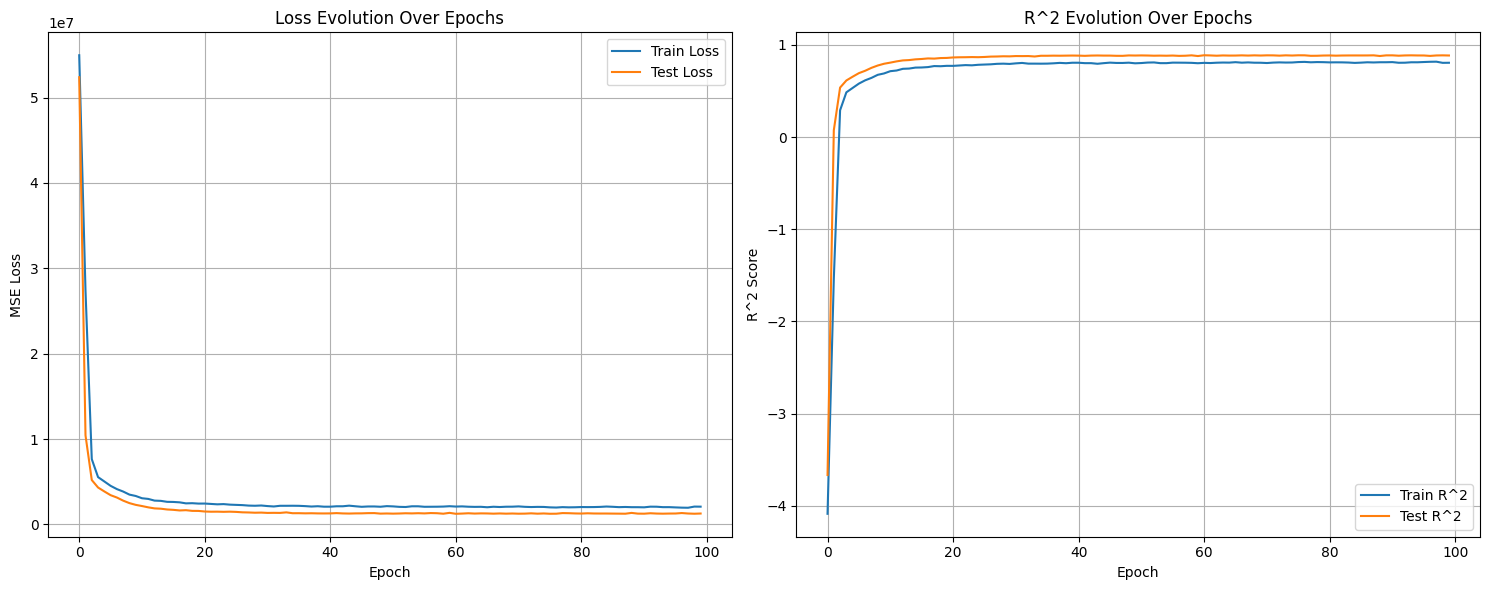

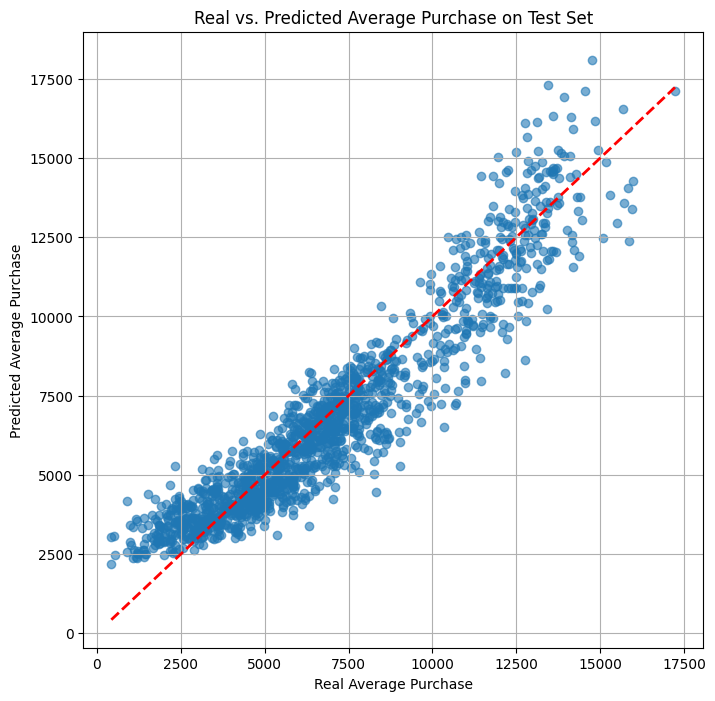

Model evaluation plots generated.


In [72]:
import matplotlib.pyplot as plt

print("Generating plots for model evaluation...")

# Plotting Loss and R^2 evolution
plt.figure(figsize=(15, 6))

# Plotting Loss
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label='Train Loss')
plt.plot(range(num_epochs), test_losses, label='Test Loss')
plt.title('Loss Evolution Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)

# Plotting R^2
plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_r2_scores, label='Train R^2')
plt.plot(range(num_epochs), test_r2_scores, label='Test R^2')
plt.title('R^2 Evolution Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('R^2 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Scatter plot of Real vs Predicted values on the test set
model.eval() # Set model to evaluation mode
with torch.no_grad():
    test_preds = model(X_test_tensor).cpu().numpy()

plt.figure(figsize=(8, 8))
plt.scatter(y_test, test_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Real Average Purchase')
plt.ylabel('Predicted Average Purchase')
plt.title('Real vs. Predicted Average Purchase on Test Set')
plt.grid(True)
plt.show()

print("Model evaluation plots generated.")

### 2b) Modelo Multilayer Perceptron (MLP) (2.5 puntos)
Entrenar un modelo de deep learning usando PyTorch que consuma el dataframe ya pre-procesado en el paso anterior.

Características para el diseño de la red:
- El modelo debe tener un mínimo de 3 capas ocultas.
- El modelo debe tener un mínimo de 32 neuronas por cada capa oculta.
- Cada capa oculta debe tener su respectiva función de activación.
- La elección de la función de activación de las capas ocultas es libre, pero se debe justificar por qué se está eligiendo esa, ya sea mediante conceptos teóricos o con resultados de pruebas empíricas.
- Analizar y justificar cuál es la mejor función de costo, algoritmo de optimización y learning rate para este modelo.
- Analizar cuál sería el mejor número de épocas para entrenar el modelo.
- Opcional: Incluir técnicas de regularización como dropout en las capas ocultas.

### 2c) Evaluación del Modelo (1 punto)
- Graficar las evoluciones por época de la función de costo y del $R^2$, tanto para el set de train como el de validation.
- Gráfica scatter de Real VS Predicho en el set de validation.
- Explicar el proceso estratégico de iteracion utilizado para conseguir los mejores resultados y justificar los resultados obtenidos.
- Un resultado aceptable sería un $R^2$ de por lo menos 0.70 para el set de validation.

### 2d) Conclusiones finales (0.5 puntos)
Redactar de manera detallada las conclusiones finales y si se cumplió con el objetivo o no.